# Lab 063 · What a synthetic causal prior encodes

[Lesson](../lessons/0063-synthetic-scm-prior.html) · [Reference](../reference/0063-synthetic-scm-prior.html) · [Reproduction contract](l063-reproduction.md)

**Route:** retrieve → explain → predict → implement → CHECK → inspect evidence → EXIT. PROVIDED cells are readable implementation and peripheral support. TODOs contain your load-bearing code; CHECKs give immediate diagnostic feedback. Complete the code before revealing teacher solutions. Core study: 35–50 minutes; lab: 45–75 minutes plus explicitly gated larger runs.

**Before reading:** Does a causal pretraining generator identify the true causal graph of a deployment table? Write your answer and justify the information boundary. Then recall one older lesson that could expose an error in this experiment.

**Evidence contract:** numerical figures labeled author-reference come from committed author measurements. They are not outputs of your current kernel. Reduced model mechanisms, pretrained reference inference, frozen-result reanalysis and paper reproduction are different tracks. Every track states its scope below.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## The prior is a distribution over learning problems

Your goal is to build a small structural causal model, trace its generated observations, and identify a concrete mismatch between that prior and a possible deployment task. In a PFN, the prior determines which tasks the model practices before seeing your table. It is part of the model's inductive bias, alongside architecture, loss and optimization. Read [TabPFN v1, Section 4 and the prior appendix](https://arxiv.org/html/2207.01848v6), then compare the [TabICL prior description](https://arxiv.org/html/2502.05564v1#S4.SS1).

An **SCM** assigns every variable a function of its parents and an exogenous noise variable: `V_j = f_j(parents_j, epsilon_j)`. A directed acyclic graph records which variables can enter each function. **Acyclic** means that a variable cannot ultimately depend on itself through a directed path, so one can evaluate nodes in topological order. Exogenous noise comes from outside the modeled graph; its independence assumptions are part of the generator, not facts inferred from an arbitrary observed table.

### A synthetic dataset generator expresses assumptions

A prior over tasks says which learning problems the pretrained predictor should expect. It can vary graph structure, function shapes, noise, observed variables and target construction. Each sampled task then generates many rows from one shared mechanism. The resulting training distribution teaches the predictor which regularities tend to transfer between context and queries.

A structural causal model, or SCM, specifies how variables are generated from their parents and exogenous noise. A directed acyclic graph defines a valid computation order. The graph is not merely a picture of correlations: its arrows identify which computed parent values enter each structural equation.

In the local generator, weights[parent,child] form a strictly upper-triangular matrix. Variables are evaluated in index order, so every parent needed by a child has already been computed. Each child receives an activated weighted parent signal plus its own noise. This convention is visible in the code and must match any hand calculation.

Sampling one graph and set of equations per row would create a different task distribution from sampling one shared mechanism for the whole context/query episode. The learner needs evidence in the context that is relevant to the query. Preserve the episode-level shared latent mechanism when constructing the generator.

The use of causal generators is an inductive-bias choice. It does not imply that the trained predictor identifies the true causal graph of a deployment table or that its ordinary predictions estimate intervention effects. Those are additional inference tasks with additional assumptions.

## Compute a graph, not just draw one

Our small generator stores `weights[parent, child]` in a strictly upper-triangular matrix. For node j, multiply already computed parent values by their edge weights, apply tanh and add that node's sampled noise. A zero entry means that edge is absent. Tanh is a bounded nonlinear function; it makes descendants nonlinear even with linear weighted parent combinations.

Start with a linear activation to check arithmetic. For noises `[1,.2,−.1]` and edges `0→1` of weight 2 and `1→2` of weight −1, node values are `[1,2.2,−2.3]`. Node 2 uses the computed value 2.2, not the original noise .2. A matrix multiplication of the raw noise by the adjacency matrix is therefore not a general SCM sampler: it skips the recursive dependence.

### Evaluate computed parents, not their raw noise

Use a simple three-node chain and temporarily choose the identity activation to make arithmetic transparent. Let noise be ε=(1,2,3), with edge weights w₀₁=2 and w₁₂=−1. Then V₀=1, V₁=2V₀+2=4, and V₂=−V₁+3=−1.

If you mistakenly use raw parent noise for the last equation, you get −ε₁+3=1. The shape of the result is correct, but the effect transmitted through V₀→V₁→V₂ has disappeared. This is why the lab's check uses a multi-edge path rather than testing only isolated parent/child pairs.

With the default tanh activation, the same convention gives V₀=1, V₁=tanh(2)+2 and V₂=tanh(−V₁)+3. Noise is added after the activation in this local function. Moving it inside tanh changes the distribution and the meaning of the noise parameter.

The upper-triangular restriction prevents cycles in this representation. A general cyclic system would require a different definition of how variables are jointly solved or evolved. Rejecting lower-triangular entries is therefore enforcing the declared model class, not an arbitrary storage preference.

Vectorizing across rows is safe because rows share the task's equations but have their own exogenous noise draws. Vectorizing across graph nodes without respecting dependencies is not safe unless the chosen operation explicitly implements the topological recurrence.

### Structural noise and measurement noise are different

Noise in a node's equation can propagate to descendants. Noise added only to an observed feature after the latent graph is evaluated changes the measurement but need not affect the latent target. These choices can create different learning problems even when marginal feature variability looks similar. A prior card should state where noise enters.

<div style="overflow-x:auto;max-width:100%">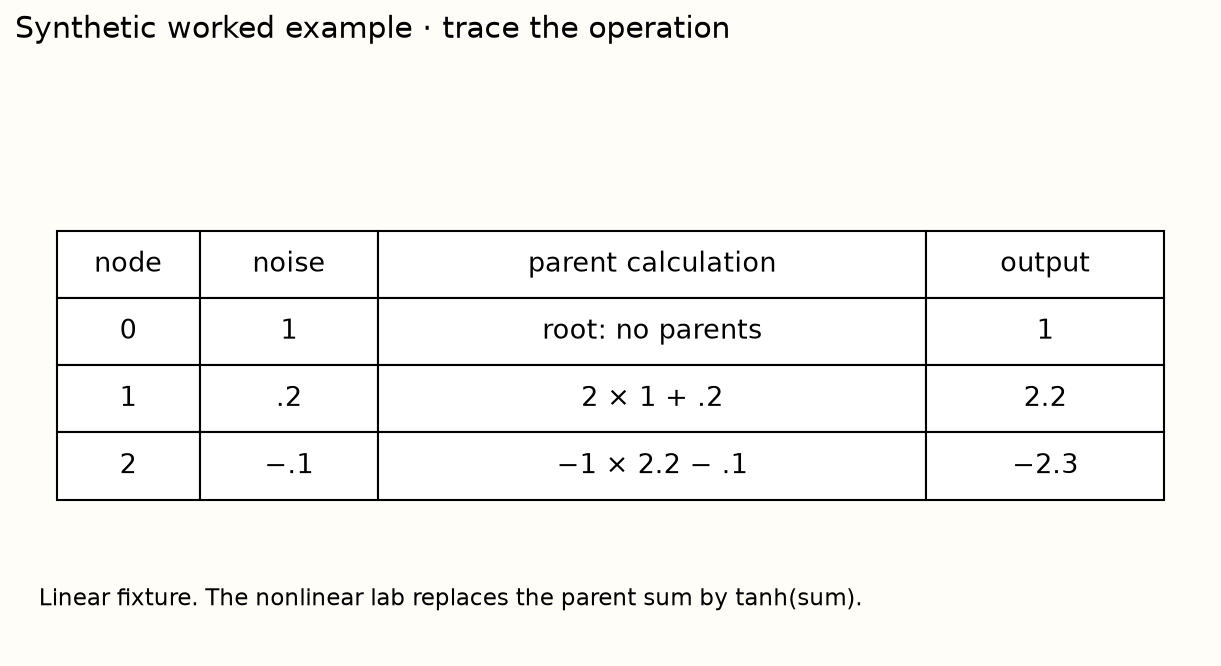</div>

*L063 mechanism: worked computation; see adjacent explanation. Scroll wide figures horizontally on small screens.*

The lab first verifies this linear fixture, then runs nonlinear four-node models with fixed noise. Reject a lower-triangular entry or a diagonal edge in this representation; silently evaluating it as if it were a DAG produces an incorrectly specified experiment. Other graph orderings are valid, but they must first be topologically reordered or evaluated by a graph algorithm.

## A paired intervention isolates one mechanism

The author run changes the edge from node 1 to node 2 while holding all exogenous noise draws fixed. Ancestors remain numerically identical; descendants may change. This pairing makes the effect of that edge visible without confounding it with different random samples. Inspect the full path from the changed parent input through the nonlinear operation to the target.

This is an **edge-mechanism intervention**. It differs from conditioning on a variable taking some observed value. It also differs from a node intervention such as `do(V_2=c)`, which replaces the entire structural assignment of node 2 with a constant. Name the operation exactly: causal vocabulary should describe the computation performed, not decorate a correlation plot.

### Hold the world’s other ingredients fixed

To isolate the effect of an edge, evaluate the same exogenous noise under the original and modified graph. In the identity-activation chain above, removing V₁→V₂ leaves V₀=1 and V₁=4 unchanged, while V₂ becomes its noise value 3. The paired change at V₂ is +4.

If you resample noise at the same time, the difference combines the edge change with a new random realization. That may be a valid comparison of distributions, but it no longer isolates the edge's effect on the same synthetic case. Pairing is the key to the clean mechanism trace.

Only descendants of the changed structural equation can change in an acyclic forward computation, provided all other equations and noises stay fixed. Ancestors should remain exactly equal in the local deterministic evaluation. This gives a strong behavioral assertion for the lab.

Removing an edge changes a mechanism. Setting a node to a fixed value with a do-intervention is another operation: it replaces that node's structural equation. Conditioning on an observed node value is different again. Do not use these terms interchangeably merely because they all involve a graph.

For the lesson's measured synthetic intervention, the conclusion is about the implemented generator. It demonstrates causal propagation inside a known SCM. It does not establish the causal effect of a real-world feature whose generating graph is unknown.

<div style="overflow-x:auto;max-width:100%">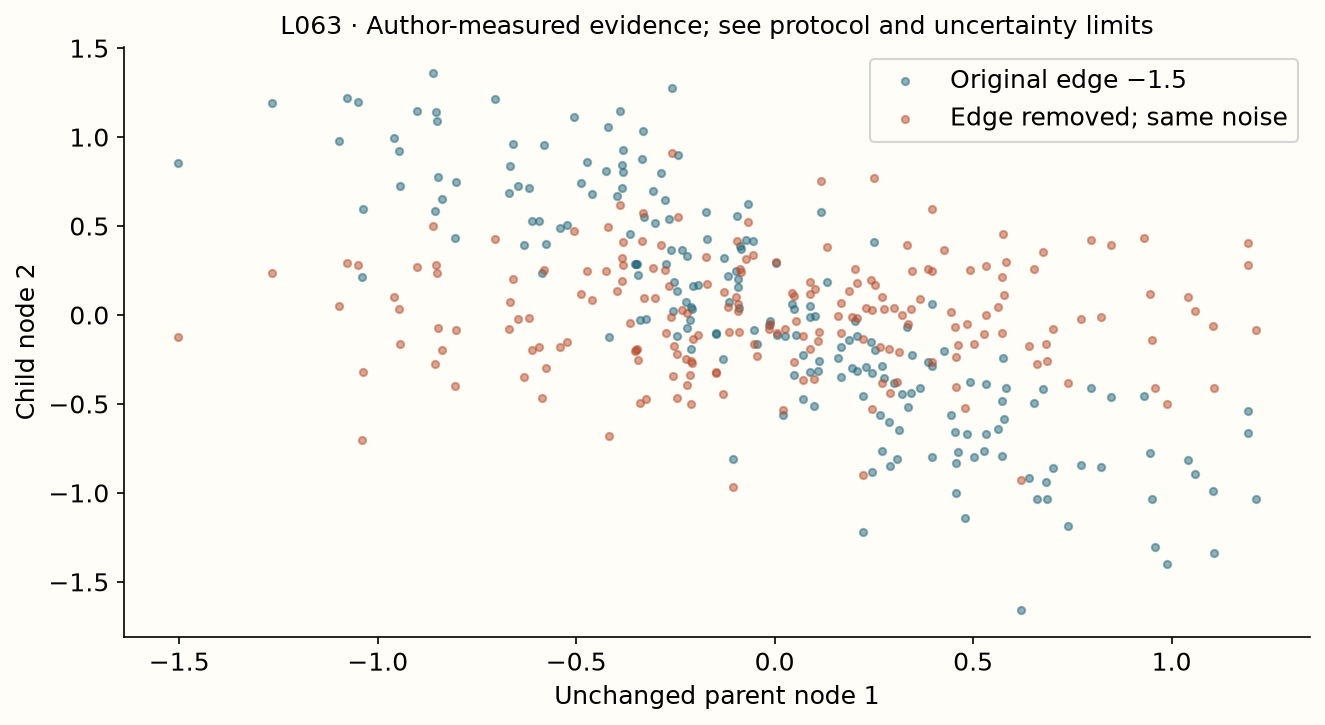</div>

*L063 results: author-reference measurements, separate from your kernel. Scroll wide figures horizontally on small screens.*

## Turn latent variables into a supervised task

An SCM alone does not specify a tabular benchmark. You must choose which generated nodes are observed features, which node becomes the target, which remain hidden, how continuous targets become classes, and which rows enter context versus query. Those observation choices can create confounding, redundant features or missing information. The same latent graph can produce very different supervised tasks when you change what the learner sees.

For classification, thresholding a generated target using statistics from all rows would let the query distribution influence task construction. Synthetic pretraining may deliberately define tasks jointly, but that is a generator contract to state, not a preprocessing recipe to copy into deployment evaluation. In the lab, record the threshold rule and use the same sampled task mechanism for context and query unless you are explicitly testing shift.

The four-node tanh generator does not reconstruct the released TabPFN prior. It omits the mixture of function families, graph/width distributions, hidden-node selections, noise distributions and preprocessing choices. The lesson mirrors topological sampling and mechanism intervention, which are independently testable load-bearing parts. A plot that looks “tabular” is not a fidelity certificate.

### Observation choices can make a task easy, hard or invalid

After generating latent variables, select which nodes become observed features and which node defines the target. If the target node is also included directly among features, the problem can become trivially leaked. The local observation function rejects this overlap and repeated feature-node selections.

A binary target can be formed by thresholding a latent target variable. The threshold is part of the task definition. Choosing it separately for training and test changes label semantics across partitions; choosing it using the full evaluation labels can introduce an unwanted dependence. Use the declared fixed threshold consistently.

Observing causes of the target, effects of the target or noisy proxies yields different predictive information. A method pretrained over one mix of these structures may transfer differently to another. This is a concrete way to reason about prior mismatch without treating “causal data” as one homogeneous category.

Class balance also depends on graph parameters, noise and threshold. A generator that produces nearly one-class episodes may teach a different inference problem from one that deliberately balances every task. Record whether balance is sampled, filtered or forced.

### Prior mismatch needs a discriminating test

If a pretrained model fails on a real table, many explanations remain possible: preprocessing, unsupported scale, limited context, optimization of a local head or the pretraining task distribution. Prior mismatch is a hypothesis among these, not an automatic diagnosis.

In a controlled synthetic study, change one generator property while holding the evaluation protocol fixed. Compare performance on matched and mismatched task families, including a baseline whose behavior you understand. If the effect follows the changed property and survives implementation checks, the evidence for that mismatch becomes stronger.

The exit prior card should specify graph sampling, structural functions, noise placement, observed nodes, target rule and shared episode variables. It should also list at least one deployment property the generator does not model. This turns an opaque synthetic-data recipe into an inspectable set of learning assumptions.

### A hidden variable can make the observed table look complicated

Suppose an unobserved variable U affects both observed X and target Y. Even a simple latent graph can create predictive dependence between X and Y. A learner receiving only X does not observe U directly; it must use the information about U carried by X and the labeled context.

Changing which latent nodes are observed can therefore change task difficulty without changing the underlying graph. Observing a nearly sufficient parent of Y can make prediction easy. Observing a noisy distant descendant can make the useful relationship weaker or nonlinear. Prior design includes this observation process, not only edge sampling.

Several latent mechanisms can induce similar or identical observed distributions. Accurate prediction from the observed table does not necessarily distinguish them. This is one reason that a predictor trained on SCM-generated data should not automatically be described as recovering causal structure.

For a controlled prior study, compare observation patterns while holding the sampled latent worlds fixed. Record which nodes became features and how targets were constructed. Then you can ask whether transfer depends on the observed information structure, rather than attributing every change to the graph's complexity or the number of nodes.

## Prior mismatch is a hypothesis, not an automatic diagnosis

If deployment has abrupt thresholds but pretraining favors smooth functions, a threshold-rich prior might help. If deployment changes its target mechanism over time while synthetic tasks remain stationary, temporal extrapolation may fail. If a necessary parent variable is unobserved, no clever prior guarantees that the target is identifiable from the supplied features.

To test a prior explanation, hold architecture, optimization steps, training-task count and evaluation data fixed, then change the prior component. Otherwise a gain could come from more compute or a different model. Compare in-prior held-out tasks, controlled out-of-prior tasks and real tasks separately. A causal generator does not mean the fitted PFN has identified the true causal graph of your database.

## Exit: produce a prior card

Submit the graph, weight matrix, topological trace, paired edge intervention and unchanged-ancestor check. Your prior card must name task-function families, noise assumptions, observed/hidden variables, class-construction rules and context/query sampling. Propose one alternative prior and one controlled evaluation that could falsify the claim that it helps. Connect it to the relational mission: which database dependency would a single-table synthetic prior fail to represent?

## Reproduction contract and task support

The visible code below implements the named operator or reduced architecture. The full pretrained model is a separately pinned reference path. Real public-table experiments use Tier A data; synthetic coin/SCM/shift tasks are Tier C mechanism isolation. Seeds, row identities, recipe budgets, versions and source/checkpoint hashes are available in the linked contract and evidence. Numerical agreement with a local operator is not a paper-table reproduction.

In [ ]:
# PROVIDED — environment, peripheral data/metric utilities
import os, sys, math, copy, re, json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold
from threadpoolctl import threadpool_limits
from IPython.display import display
for directory in [Path.cwd(), Path.cwd()/'labs', Path.cwd().parent]:
    if (directory/'relkit').is_dir():
        ROOT=directory.resolve(); sys.path.insert(0,str(ROOT)); break
else:
    raise RuntimeError('Run the Colab bootstrap or start in the course repository')
torch.set_num_threads(1)
from relkit.foundation_benchmark import random_task, encode_train
print('CPU mechanism track; official checkpoint reruns use an isolated subprocess after EXIT.')

In [ ]:
# PROVIDED — scm_experiment; inspect the live function calls
def scm_experiment():
    rng=np.random.default_rng(63);noise=rng.normal(size=(1500,4))*.3
    w=np.array([[0.,1.4,0.,0.],[0.,0.,-1.5,1.],[0.,0.,0.,1.2],[0.,0.,0.,0.]])
    base=sample_scm(noise,w);changed=w.copy();changed[1,2]=0.;cut=sample_scm(noise,changed)
    return dict(scope='Paired synthetic intervention with identical exogenous noise',weights=w.tolist(),changed_weights=changed.tolist(),
        base=base[:200].tolist(),intervention=cut[:200].tolist(),
        downstream_mean_absolute_change=np.abs(base-cut).mean(0).tolist(),
        same_ancestors=bool(np.array_equal(base[:,:2],cut[:,:2])),verdict='MECHANISM_ONLY',
        limitation='Four-node tanh DAG, fixed observation choices; not the released TabPFN prior mixture')

## TODO 1 · sample_scm

**Goal:** Evaluate the upper-triangular DAG in topological order; use computed parents, not raw parent noise.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 1 — sample_scm
def sample_scm(noise, weights, activation=np.tanh):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 1 — sample_scm
noise=np.array([[1.,.2,-.1]])
w=np.array([[0.,2.,0.],[0.,0.,-1.],[0.,0.,0.]])
np.testing.assert_allclose(sample_scm(noise,w,lambda x:x),[[1.,2.2,-2.3]])
try: sample_scm(noise,w.T)
except ValueError: pass
else: raise AssertionError('This implementation requires topologically ordered weights')

print("PASS: sample_scm")

## TODO 2 · observe_scm

**Goal:** Build observed X and binary y with a fixed threshold; reject target inclusion or repeated feature nodes.

**Why it matters:** a wrong implementation can produce a plausible-looking experiment while violating this lesson's prediction contract. Before coding, name one input that should fail or one intervention that should leave the result unchanged.

**Hint boundary:** reason from the worked example and the function contract; the CHECK verifies behavior, not a required code layout.

In [ ]:
# TODO 2 — observe_scm
def observe_scm(values, feature_nodes, target_node, threshold):
    raise NotImplementedError("Implement the stated operation")

In [ ]:
# CHECK 2 — observe_scm
values=np.array([[0.,1.,2.],[3.,4.,-1.]])
x,y=observe_scm(values,[0,1],2,threshold=0)
np.testing.assert_array_equal(y,[1,0]);np.testing.assert_array_equal(x,values[:,:2])
try: observe_scm(values,[0,2],2,0)
except ValueError: pass
else: raise AssertionError('Target included as a feature')

print("PASS: observe_scm")

## Run your live implementation

Predict the outcome before execution. This cell calls the functions you just wrote. Changing a TODO must change the corresponding computation or make a CHECK fail. The text printed with the result identifies whether this is a small training run, a mechanism test or a reanalysis of committed measurements.

In [ ]:
# PROVIDED — experiment driven by your live functions
trial=scm_experiment()
assert trial['same_ancestors']
values=np.asarray(trial['base']);x,y=observe_scm(values,[0,1,2],3,0.)
print('Observed X/y:',x.shape,y.shape,'ancestor change:',trial['downstream_mean_absolute_change'][:2])

## Audit author-reference evidence

Inspect the measured results below independently of your smoke experiment. A fresh smoke may use a smaller budget. Preserve the protocol difference rather than forcing numerical agreement with a different run. The committed prediction arrays let you reconstruct scores without downloading pretrained weights.

In [ ]:
# PROVIDED — readable evidence, never impersonating current-kernel training
author=json.loads((ROOT/'_verify_l063_results.json').read_text())
print('AUTHOR REFERENCE:',author.get('scope',author.get('note','Declared checkpoint experiment')))
print('Evidence verdict:',author.get('verdict'))
rows=author.get('records',author.get('summary',[]))
if isinstance(rows,list) and rows:
    display(pd.DataFrame(rows).drop(columns=['predictions','targets','history','context_ids','task_losses'],errors='ignore').head(24))
if 63 in [60,70]:
    for regime,summary in author['summary'].items():
        print(regime,summary['mean_ranks'],'Friedman p=',summary['friedman_p'],'CD=',summary['nemenyi_cd'])

## EXIT TICKET · submit an executable argument

Provide your code output plus a 30–100 word verdict: which implementation ran, what information it could use, what evidence supports the result, and which paper claim remains untested. Include an unexpected or failed case and a next discriminating experiment. The length check below only enforces an attempt; the tutor grades your reasoning. Do not infer personal mastery from a green code cell.

In [ ]:
# TODO — written verdict; paste the resulting artifact and explanation to the tutor
verdict=''
assert len(verdict.split())>=30, 'Write a defensible verdict; a passing code cell is not the explanation'
ticket={'lesson':63,'checks':'passed in this kernel','trial':trial,'verdict':verdict,
        'paper_reproduction':'NOT_ESTABLISHED','author_reference':'_verify_l063_results.json'}
folder=ROOT/'data/cache/foundation';folder.mkdir(parents=True,exist_ok=True)
path=folder/'student-l063-exit.json'
path.write_text(json.dumps(ticket,indent=2,default=lambda x:x.item() if hasattr(x,'item') else x.tolist(),allow_nan=False)+'\n')
print('EXIT artifact:',path)

## NEXT STEP · reproduce or scale the declared track

Read [the exact reproduction contract](l063-reproduction.md) before increasing resources. The gate below invokes the shared runner in a subprocess; historical versions are installed into isolated package directories so v1 and v2 cannot silently replace one another. It may download the pinned checkpoint. Larger runs remain INCOMPARABLE wherever material paper-protocol gaps remain. A full paper preset deliberately fails until the original protocol is implemented.

For unattended CPU execution: `modal run --detach modal/foundation_repro.py --lesson 63 --preset closer`. This is a supplied operator, not evidence that a cloud job was run.

In [ ]:
# PROVIDED — explicit post-EXIT gate (OFF by default)
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    import subprocess
    subprocess.run([sys.executable,str(ROOT/'_run_foundation.py'),'--lesson','63',
                    '--preset','closer','--output',str(ROOT/'data/cache/foundation/l063-closer.json')],check=True)
else:
    print('Scale-up NOT_RUN in this kernel. See the protocol ledger before enabling.')